In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
import math

In [2]:
from google.colab import drive
drive.mount('/content/drive')

data_path = "/content/drive/MyDrive/Colab Notebooks/train.csv"

df = pd.read_csv(data_path)

Mounted at /content/drive


In [5]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [3]:
df_new = df
bad_names = ['LotFrontage', 'MasVnrArea', 'GarageYrBlt', 'Id','MiscVal','MSSubClass','PoolArea','BedroomAbvGr','KitchenAbvGr','YrSold','MoSold','3SsnPorch','OpenPorchSF','BsmtFullBath','BsmtHalfBath','FullBath','HalfBath','LowQualFinSF','EnclosedPorch','ScreenPorch','BsmtFinSF2']
for name, data in df.items():
  try:
    num = float(data[0])
    if math.isnan(data[0]):
      df_new = df_new.drop(name, axis=1)
  except:
    df_new = df_new.drop(name, axis=1)
  if name in bad_names:
    df_new = df_new.drop(name, axis=1)

print(df_new.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 17 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   LotArea       1460 non-null   int64
 1   OverallQual   1460 non-null   int64
 2   OverallCond   1460 non-null   int64
 3   YearBuilt     1460 non-null   int64
 4   YearRemodAdd  1460 non-null   int64
 5   BsmtFinSF1    1460 non-null   int64
 6   BsmtUnfSF     1460 non-null   int64
 7   TotalBsmtSF   1460 non-null   int64
 8   1stFlrSF      1460 non-null   int64
 9   2ndFlrSF      1460 non-null   int64
 10  GrLivArea     1460 non-null   int64
 11  TotRmsAbvGrd  1460 non-null   int64
 12  Fireplaces    1460 non-null   int64
 13  GarageCars    1460 non-null   int64
 14  GarageArea    1460 non-null   int64
 15  WoodDeckSF    1460 non-null   int64
 16  SalePrice     1460 non-null   int64
dtypes: int64(17)
memory usage: 194.0 KB
None


LotArea
R-squared: 0.0696133153821118


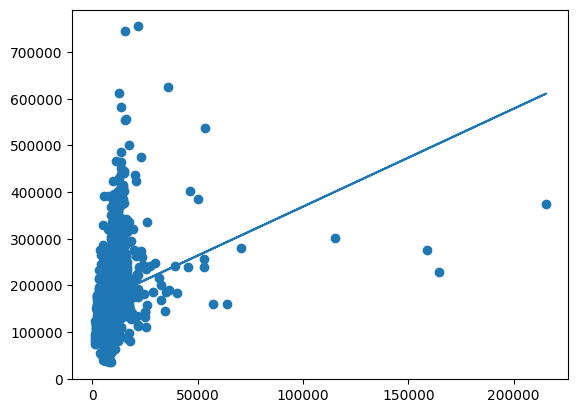

OverallQual
R-squared: 0.625651892462118


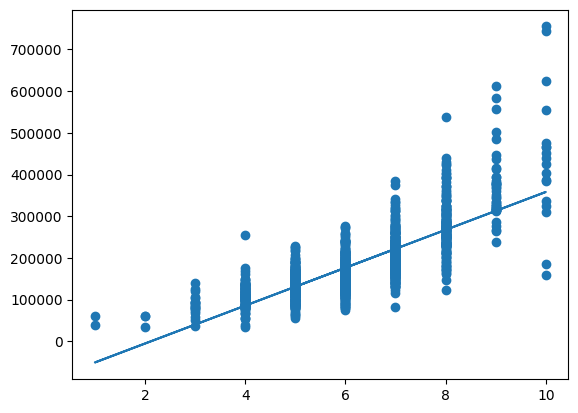

OverallCond
R-squared: 0.00606154023811889


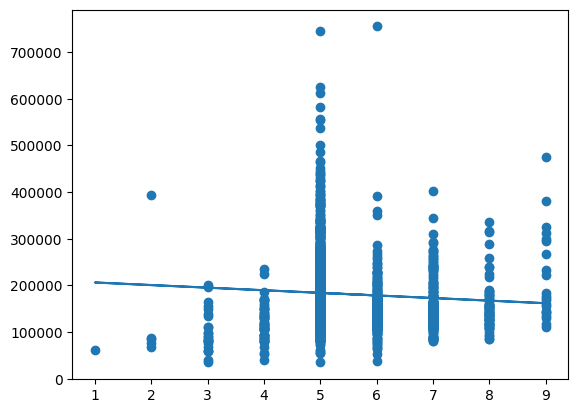

YearBuilt
R-squared: 0.27342162073249154


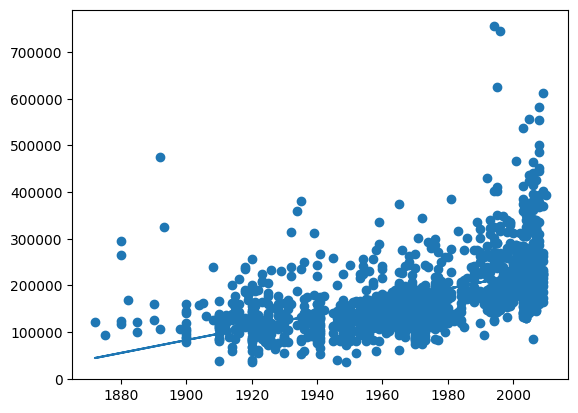

YearRemodAdd
R-squared: 0.25715139084530325


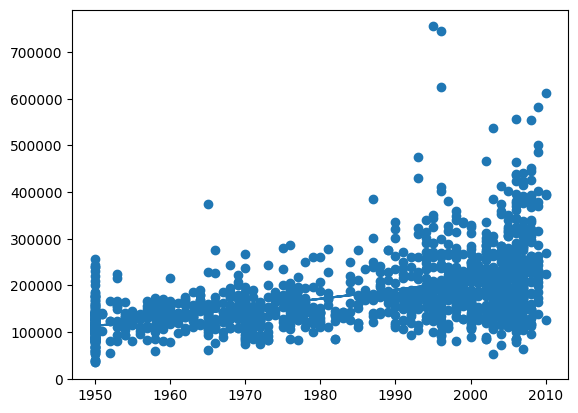

BsmtFinSF1
R-squared: 0.14932026665622333


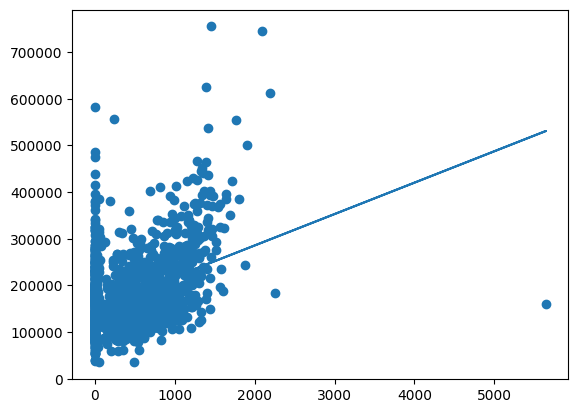

BsmtUnfSF
R-squared: 0.04600128671622783


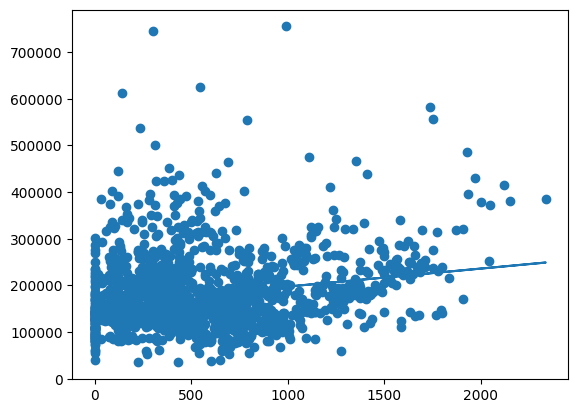

TotalBsmtSF
R-squared: 0.37648109325168655


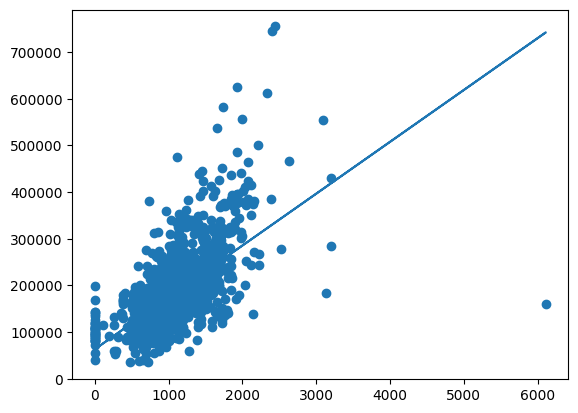

1stFlrSF
R-squared: 0.36705686969596585


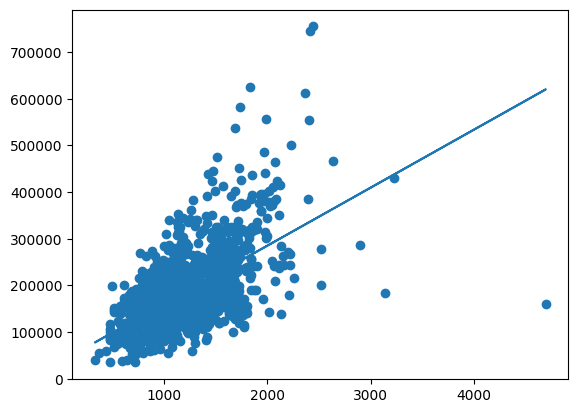

2ndFlrSF
R-squared: 0.10197407763119004


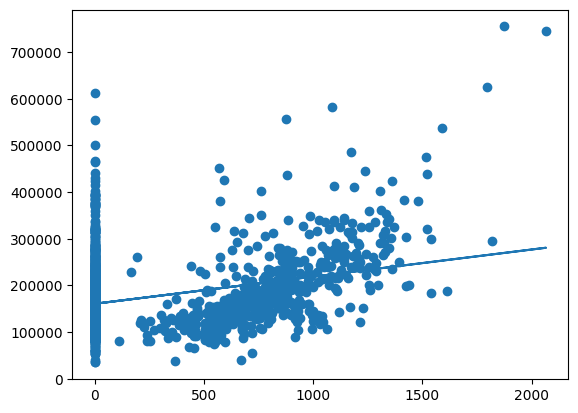

GrLivArea
R-squared: 0.5021486502718042


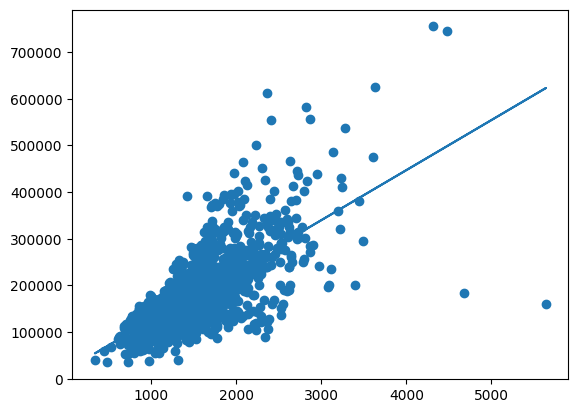

TotRmsAbvGrd
R-squared: 0.2848604068044379


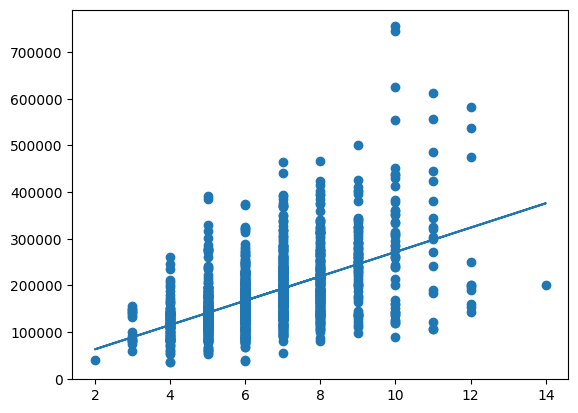

Fireplaces
R-squared: 0.21802253859013498


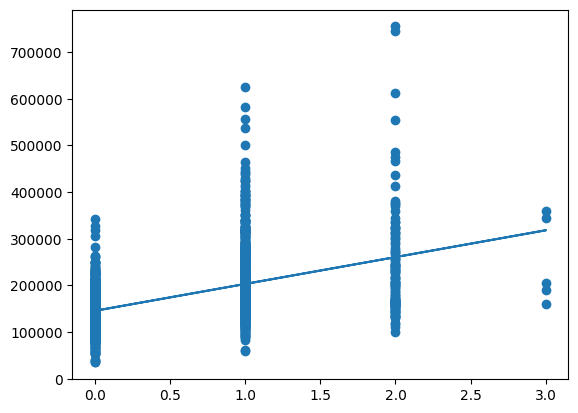

GarageCars
R-squared: 0.41012393993308693


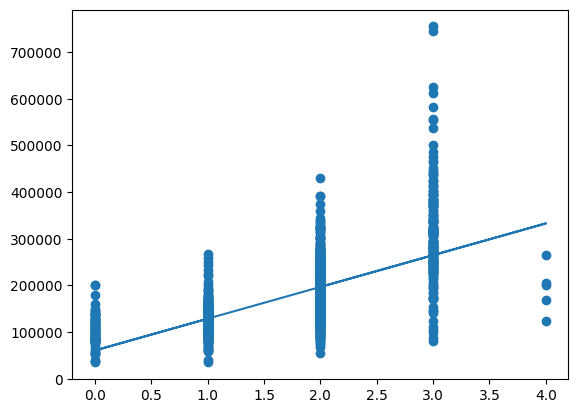

GarageArea
R-squared: 0.388666759031819


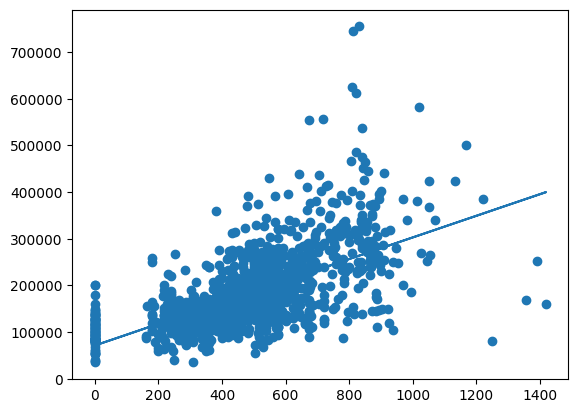

WoodDeckSF
R-squared: 0.10524408301655919


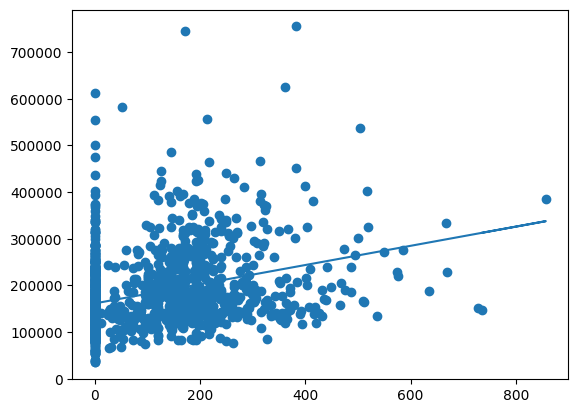

SalePrice
R-squared: 1.0


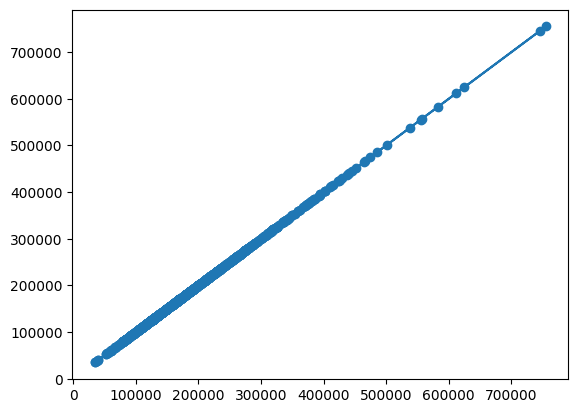

In [4]:
prices = df_new['SalePrice'].tolist()
for name, data in df_new.items():
  print(name)
  data = np.array(data).reshape(-1, 1)
  model = sklearn.linear_model.LinearRegression()
  model.fit(data, prices)
  guesses = model.predict(data)
  print('R-squared: ' + str(model.score(data, prices)))
  plt.scatter(data, prices)
  plt.plot(data, guesses)
  plt.show()

In [5]:
X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(
    df_new.drop('SalePrice', axis=1), df_new['SalePrice'], test_size=0.2,random_state=42)

a_val = 1
a_vals = []
coefs = []
#model = sklearn.linear_model.LinearRegression()

for i in range(10):
  a_vals.append(math.log10(a_val))
  model = sklearn.linear_model.Ridge(alpha=a_val)
  model.fit(X_train, y_train)
  guesses = model.predict(X_test)
  print('Iteration ' + str(i + 1) + ' MSE: ' + str(sklearn.metrics.mean_squared_error(guesses, y_test)))
  print('Iteration ' + str(i + 1) + ' R-squared: ' + str(model.score(X_test, y_test)))
  coefs.append(model.coef_)
  a_val = a_val * 10

Iteration 1 MSE: 1452608495.010462
Iteration 1 R-squared: 0.8106197238848378
Iteration 2 MSE: 1451076316.431525
Iteration 2 R-squared: 0.8108194779158335
Iteration 3 MSE: 1445160224.8620288
Iteration 3 R-squared: 0.8115907738698378
Iteration 4 MSE: 1507706686.2145796
Iteration 4 R-squared: 0.8034364321035196
Iteration 5 MSE: 1675589733.261832
Iteration 5 R-squared: 0.78154909087285
Iteration 6 MSE: 1716413632.8694255
Iteration 6 R-squared: 0.7762267749106759
Iteration 7 MSE: 1777848394.5962973
Iteration 7 R-squared: 0.7682173682612812
Iteration 8 MSE: 1962762471.2449708
Iteration 8 R-squared: 0.7441096482434013
Iteration 9 MSE: 2420376189.764767
Iteration 9 R-squared: 0.6844493800671912
Iteration 10 MSE: 4616191987.372714
Iteration 10 R-squared: 0.39817527147055043


In [6]:
scaler = sklearn.preprocessing.StandardScaler()
hold_std = scaler.fit_transform(df_new)
df_new_std = pd.DataFrame(hold_std)

X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(
    df_new_std.drop(16, axis=1), df_new_std[16], test_size=0.2,random_state=42)

a_val = 1
a_vals_new = []
coefs_new = []
#model = sklearn.linear_model.LinearRegression()

for i in range(10):
  a_vals_new.append(math.log10(a_val))
  model = sklearn.linear_model.Ridge(alpha=a_val)
  model.fit(X_train, y_train)
  guesses = model.predict(X_test)
  print('Iteration ' + str(i + 1) + ' MSE: ' + str(sklearn.metrics.mean_squared_error(guesses, y_test)))
  print('Iteration ' + str(i + 1) + ' R-squared: ' + str(model.score(X_test, y_test)))
  coefs_new.append(model.coef_)
  a_val = a_val * 10

Iteration 1 MSE: 0.2302922230133179
Iteration 1 R-squared: 0.8106463370444141
Iteration 2 MSE: 0.2302935630245471
Iteration 2 R-squared: 0.810645235244139
Iteration 3 MSE: 0.23330775817561838
Iteration 3 R-squared: 0.8081668671722597
Iteration 4 MSE: 0.28053235917020264
Iteration 4 R-squared: 0.7693372833377097
Iteration 5 MSE: 0.663013050720976
Iteration 5 R-squared: 0.4548493731196722
Iteration 6 MSE: 1.1176439371012306
Iteration 6 R-squared: 0.08103725518346383
Iteration 7 MSE: 1.2064971786506564
Iteration 7 R-squared: 0.00797926593521947
Iteration 8 MSE: 1.2161882775315451
Iteration 8 R-squared: 1.0933148510861024e-05
Iteration 9 MSE: 1.2171661150767281
Iteration 9 R-squared: -0.0007930762901631194
Iteration 10 MSE: 1.2172639868304098
Iteration 10 R-squared: -0.0008735495897691514


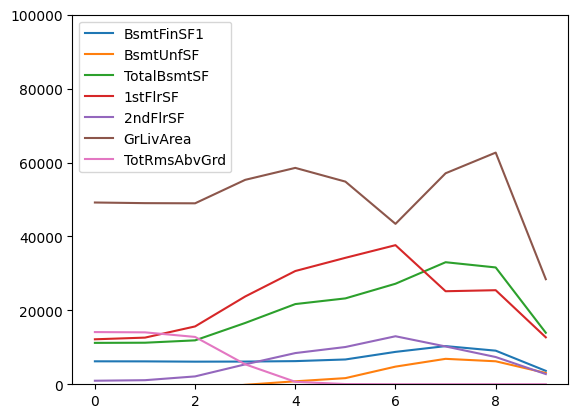

In [20]:
interest = list(df_new.columns)
interest = ['OverallQual','GrLivArea']
interest = ['YearBuilt','YearRemodAdd','GrLivArea']
interest = ['GarageCars','GarageArea']
interest = ['BsmtFinSF1','BsmtUnfSF','TotalBsmtSF','1stFlrSF','2ndFlrSF','GrLivArea','TotRmsAbvGrd']

for i in range(16):
  if df_new.columns[i] in interest:
    feature = []
    for j in range(len(coefs)):
      feature.append(coefs[j][i] * np.mean(df_new[df_new.columns[i]]))
    plt.plot(a_vals, feature)
plt.legend(interest)
plt.ylim(0, 100000)
plt.show()

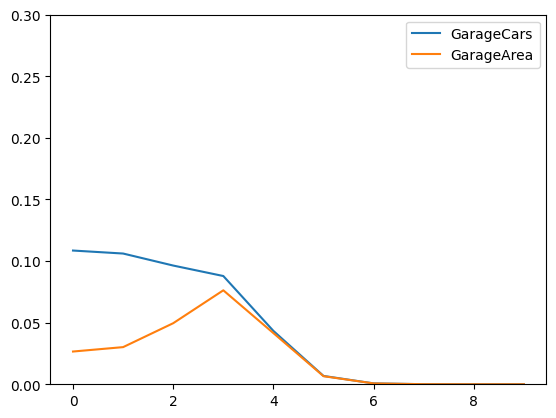

In [19]:
interest = list(df_new.columns)
interest = ['OverallQual','GrLivArea']
interest = ['YearBuilt','YearRemodAdd','GrLivArea']
interest = ['GarageCars','GarageArea']
#interest = ['BsmtFinSF1','BsmtUnfSF','TotalBsmtSF','1stFlrSF','2ndFlrSF','GrLivArea','TotRmsAbvGrd']

for i in range(16):
  if df_new.columns[i] in interest:
    feature = []
    for j in range(len(coefs)):
      feature.append(coefs_new[j][i])
    plt.plot(a_vals_new, feature)
plt.legend(interest)
plt.ylim(0, 0.3)
plt.show()